# Week 1: thresholded Branin active-learning loop

Branin is the measurable Week 1 test. Its threshold boundary is known, so after every labelled evaluation we can compute the exact fraction of test points classified incorrectly.

In [2]:
from pathlib import Path
import json
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from IPython.display import Image, display
from src.branin_week1 import run_experiment

## Run three reproducible seeds

Each seed gets a 1,500-point pool and an independent 4,000-point test set. Only the selected pool label is revealed at each iteration.

In [3]:
output_dir = ROOT / 'outputs' / 'branin_week1'
runs = run_experiment(output_dir=output_dir)
summary = json.loads((output_dir / 'summary.json').read_text(encoding='utf-8'))
print(f"Threshold: {summary['threshold']:.6f}")
print(f"Mean error: {summary['mean_initial_error']:.3f} -> {summary['mean_final_error']:.3f}")

Threshold: 29.121261
Mean error: 0.337 -> 0.060


## A. Exact thresholded-Branin dataset

The black curve is the exact boundary, not a model prediction.

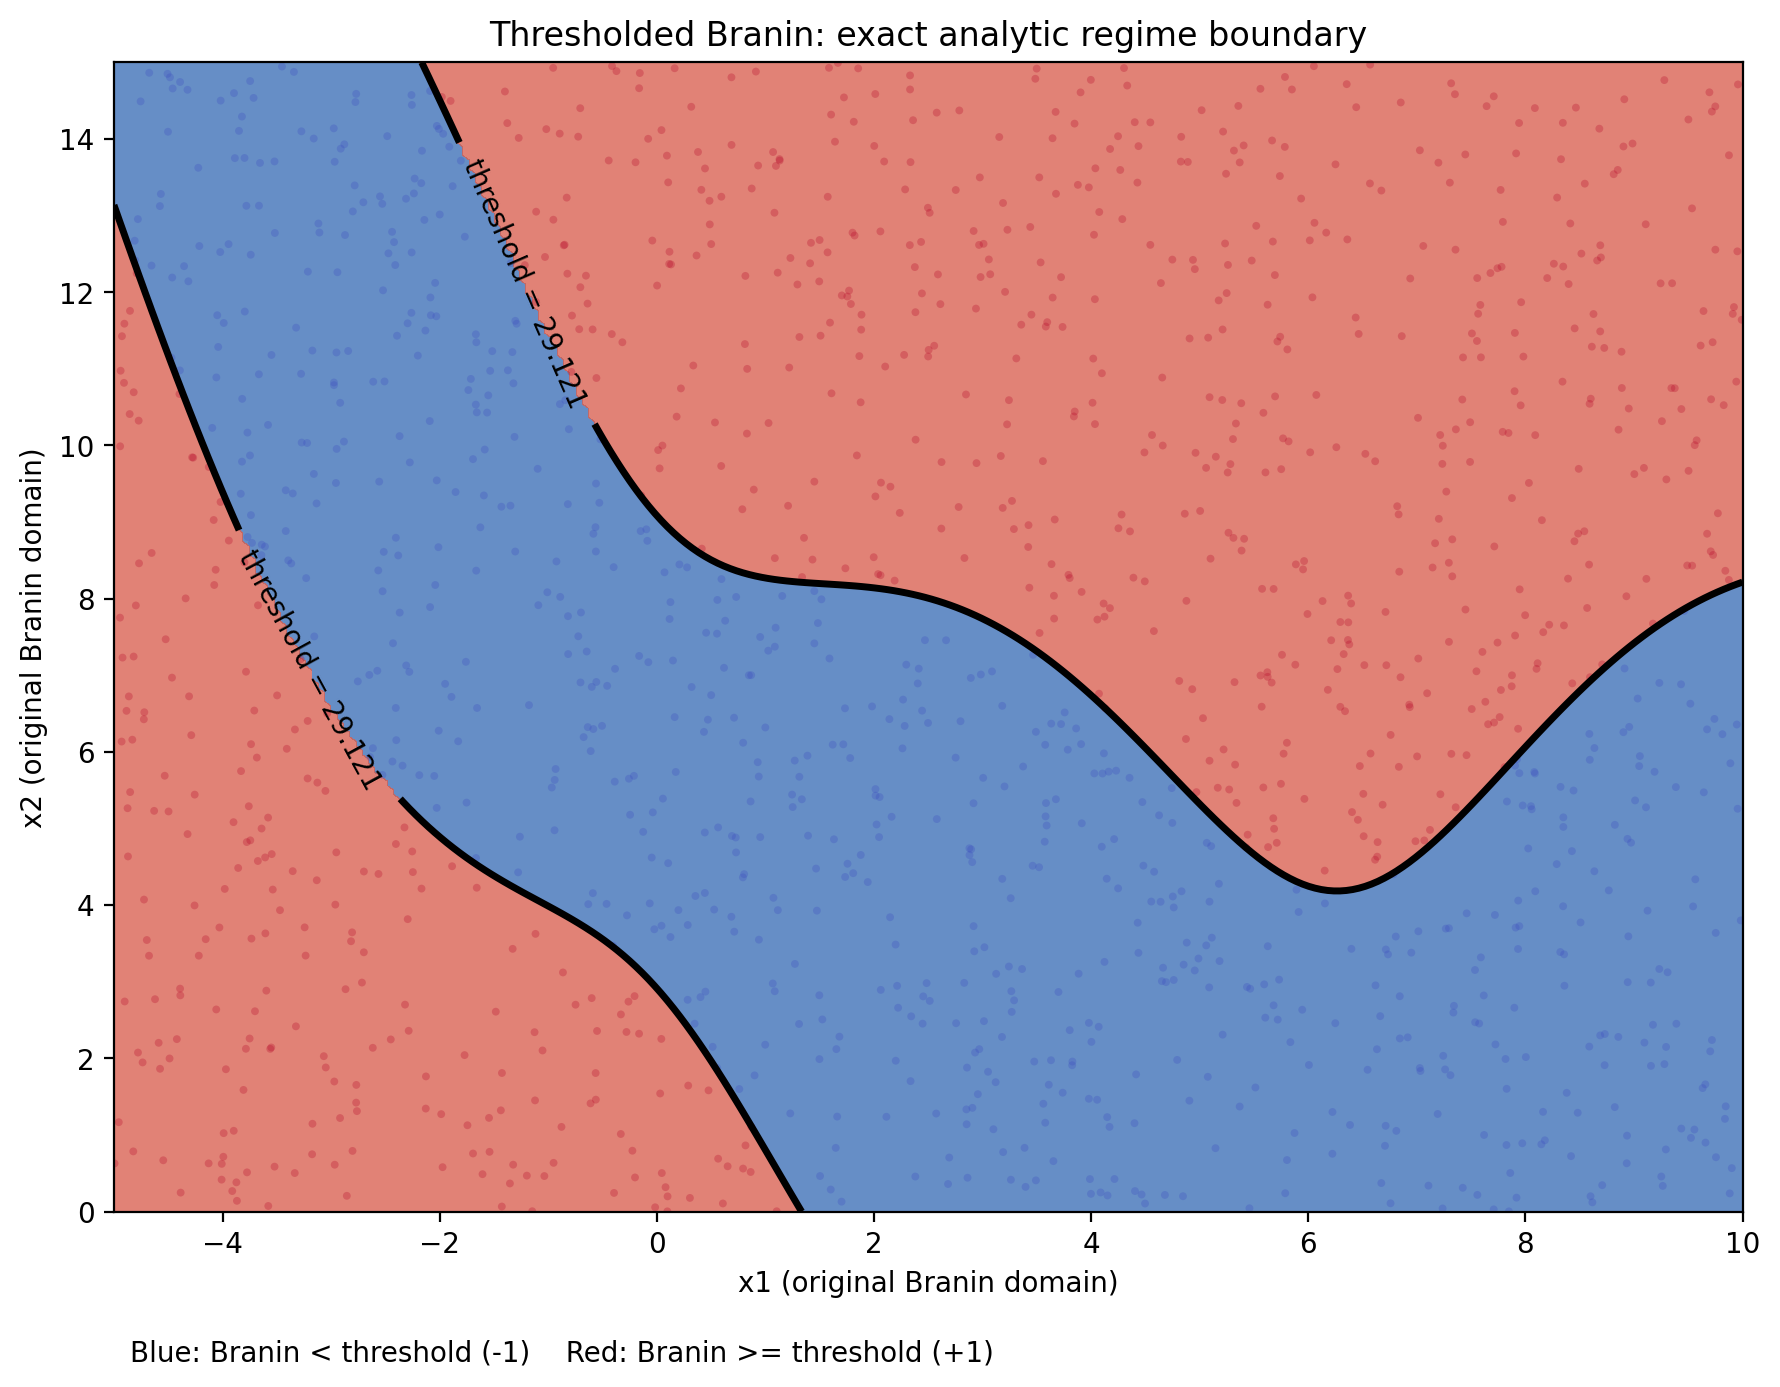

In [4]:
display(Image(filename=str(output_dir / 'dataset_overview.png')))

## B. Boundary learning at 6, 20, and 50 labels

Black is the GP's current `mu=0` boundary; yellow dashed is the exact Branin boundary.

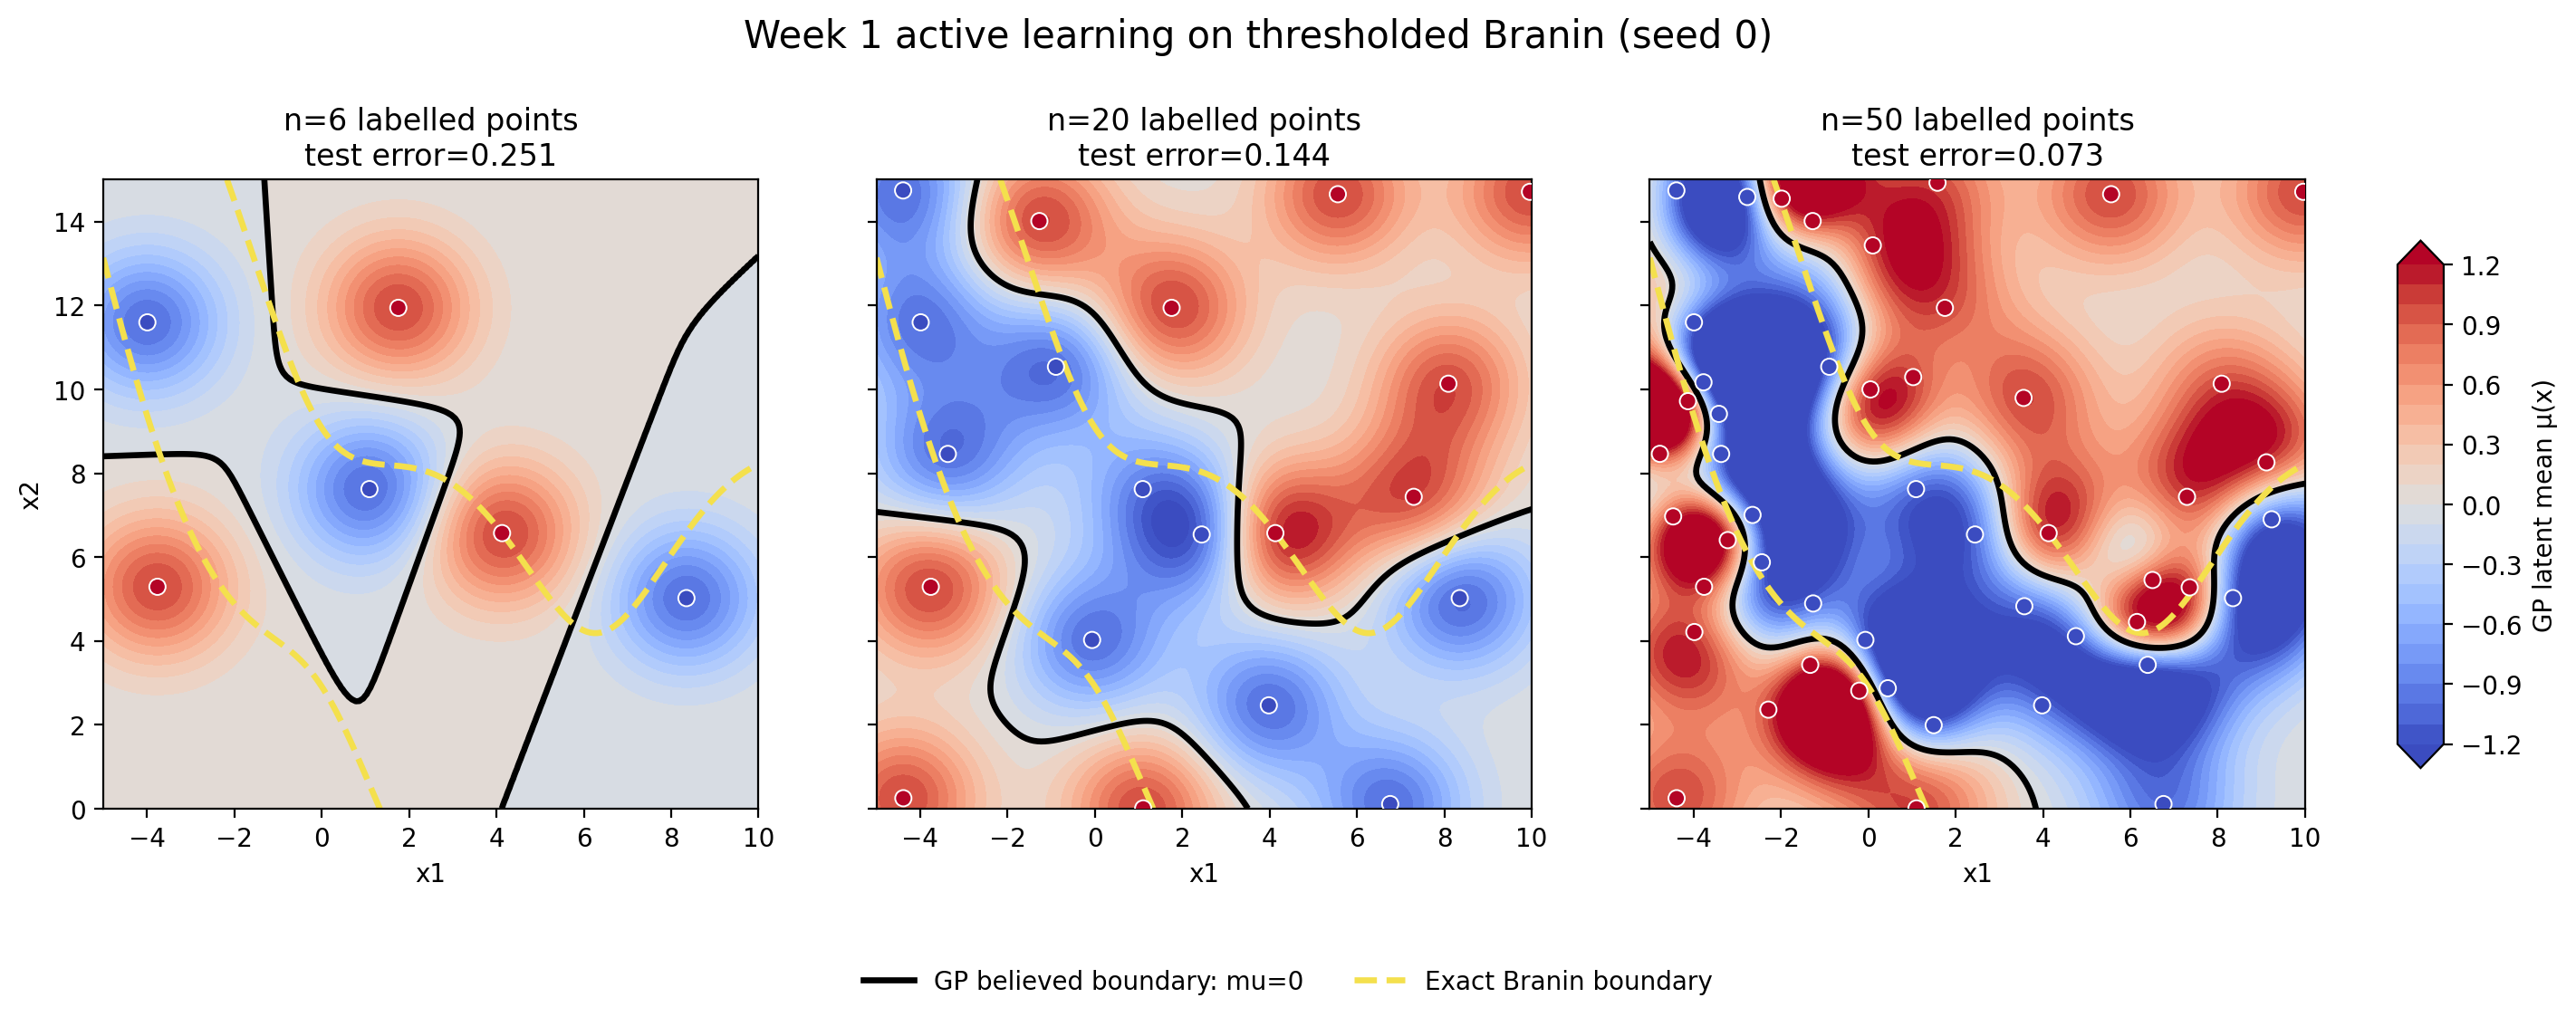

In [5]:
display(Image(filename=str(output_dir / 'active_learning_snapshots_seed0.png')))

## C. Numeric error against the exact labels

The curve may move upward at individual steps. The important check is the overall trend over the full budget and across seeds.

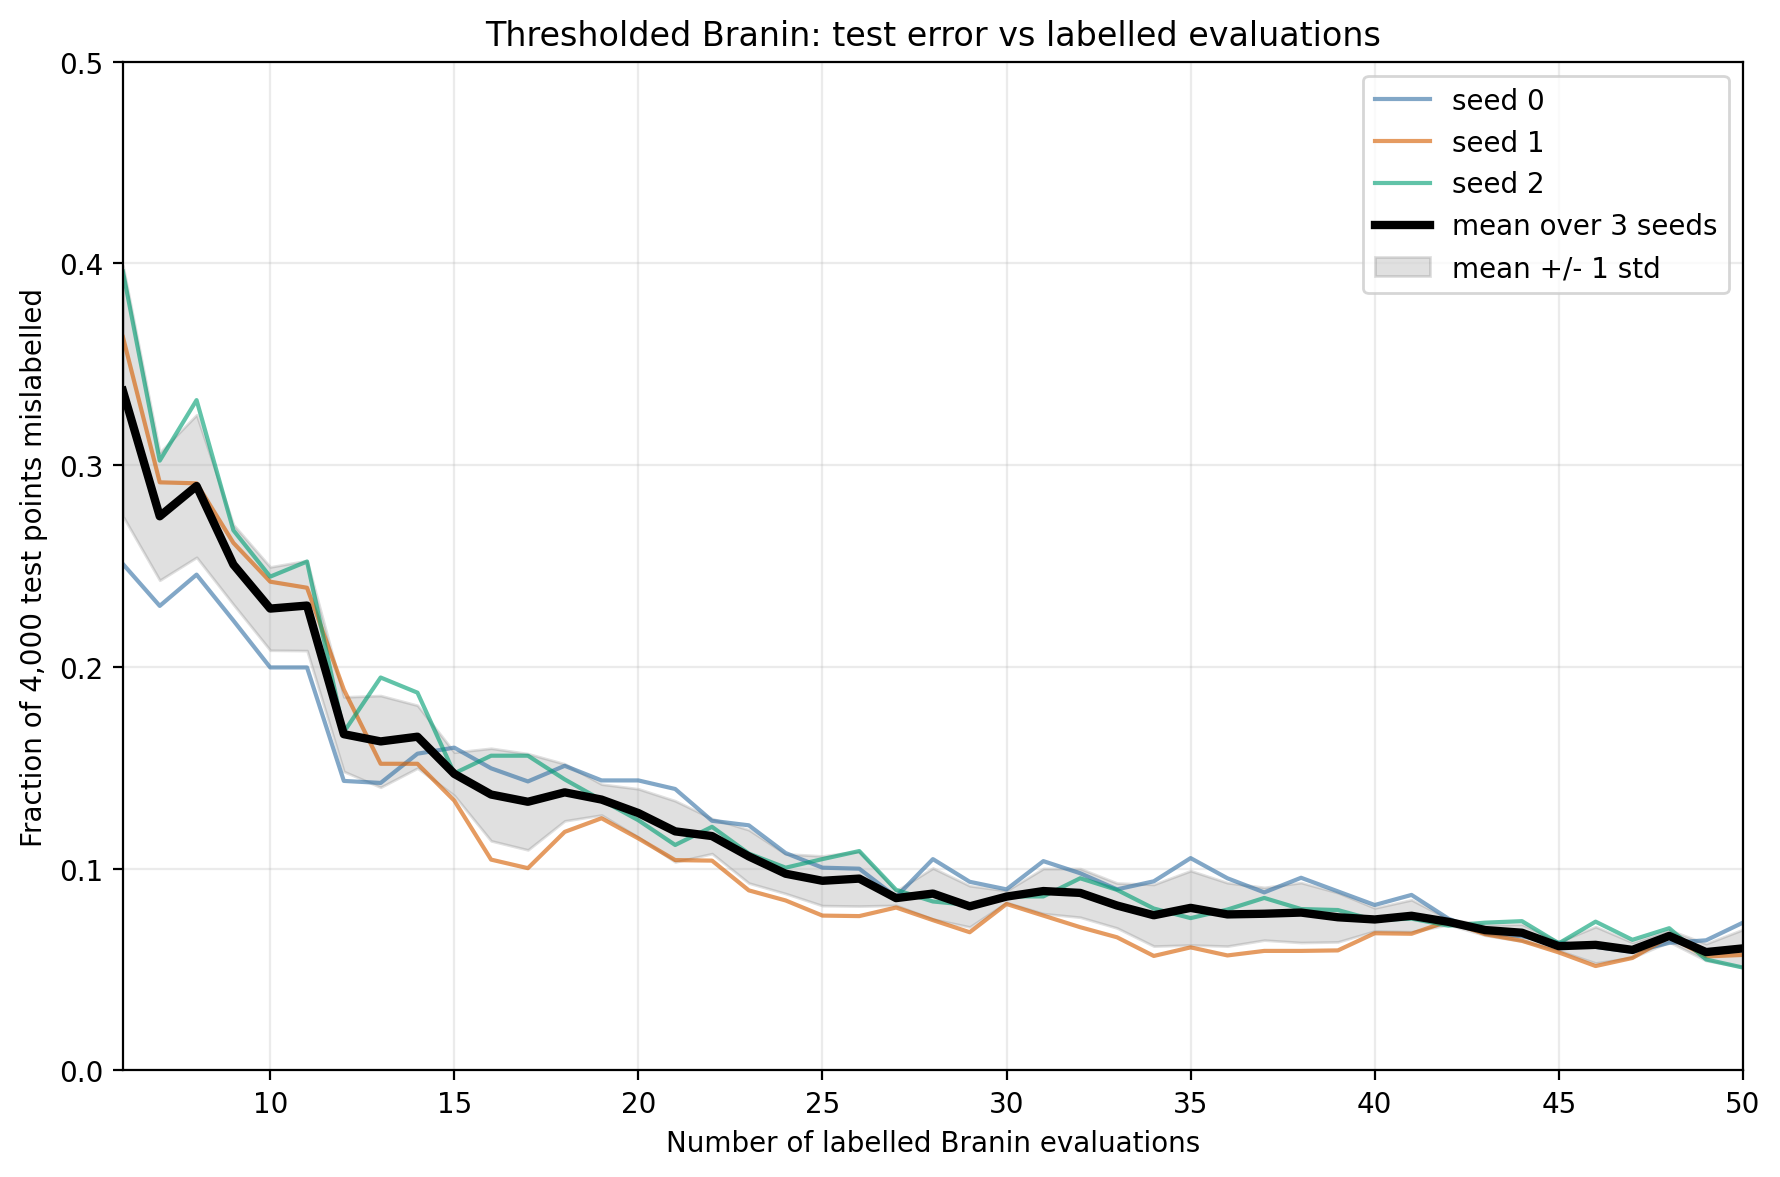

{'0': {'initial': 0.251, 'final': 0.07325},
 '1': {'initial': 0.3635, 'final': 0.05725},
 '2': {'initial': 0.396, 'final': 0.051}}

In [6]:
display(Image(filename=str(output_dir / 'error_vs_evaluations.png')))
{seed: {'initial': values['initial_error'], 'final': values['final_error']} for seed, values in summary['per_seed'].items()}

In [7]:
import json
import pandas as pd

with open("../outputs/branin_week1/summary.json", "r") as f:
    summary = json.load(f)

summary.keys()

dict_keys(['experiment', 'threshold', 'threshold_percentile', 'threshold_estimation_seed', 'threshold_estimation_sample_size', 'domain', 'pool_size_per_seed', 'test_size_per_seed', 'initial_labelled_size', 'total_budget', 'seeds', 'selection_rule', 'prediction_rule', 'error_definition', 'initial_design', 'model_note', 'kernel_note', 'per_seed', 'mean_initial_error', 'mean_final_error', 'all_seeds_finish_below_initial_error'])

In [8]:
rows = []

for seed, result in summary["per_seed"].items():
    rows.append({
        "seed": seed,
        "initial_error": result["initial_error"],
        "final_error": result["final_error"],
        "improved": result["final_error_lower_than_initial"],
        "initial_design_attempts": result["initial_design_resampling_attempts"],
    })

df = pd.DataFrame(rows)
df

,seed,initial_error,final_error,improved,initial_design_attempts
0,0,0.2510,0.07325,True,1
1,1,0.3635,0.05725,True,1
2,2,0.3960,0.05100,True,2


In [9]:
general_info = {
    "experiment": summary["experiment"],
    "threshold": summary["threshold"],
    "threshold_percentile": summary["threshold_percentile"],
    "threshold_estimation_seed": summary["threshold_estimation_seed"],
    "threshold_estimation_sample_size": summary["threshold_estimation_sample_size"],
    "x1_domain": summary["domain"]["x1"],
    "x2_domain": summary["domain"]["x2"],
    "pool_size_per_seed": summary["pool_size_per_seed"],
    "test_size_per_seed": summary["test_size_per_seed"],
    "initial_labelled_size": summary["initial_labelled_size"],
    "total_budget": summary["total_budget"],
    "seeds": summary["seeds"],
    "selection_rule": summary["selection_rule"],
    "prediction_rule": summary["prediction_rule"],
    "error_definition": summary["error_definition"],
    "initial_design": summary["initial_design"],
    "model_note": summary["model_note"],
}

general_df = pd.DataFrame(
    [{"field": key, "value": value} for key, value in general_info.items()]
)

general_df

,field,value
0,experiment,thresholded_branin_week1
1,threshold,29.121261
2,threshold_percentile,45.0
3,threshold_estimation_seed,2026
4,threshold_estimation_sample_size,20000
5,x1_domain,"[-5.0, 10.0]"
6,x2_domain,"[0.0, 15.0]"
7,pool_size_per_seed,1500
8,test_size_per_seed,4000
9,initial_labelled_size,6


In [10]:
seed_rows = []

for seed, result in summary["per_seed"].items():
    seed_rows.append({
        "seed": int(seed),
        "initial_error": result["initial_error"],
        "final_error": result["final_error"],
        "absolute_improvement": result["initial_error"] - result["final_error"],
        "relative_improvement_%": 100 * (result["initial_error"] - result["final_error"]) / result["initial_error"],
        "final_lower_than_initial": result["final_error_lower_than_initial"],
        "initial_design_attempts": result["initial_design_resampling_attempts"],
    })

seed_df = pd.DataFrame(seed_rows)

seed_df

,seed,initial_error,final_error,absolute_improvement,relative_improvement_%,final_lower_than_initial,initial_design_attempts
0,0,0.2510,0.07325,0.17775,70.816733,True,1
1,1,0.3635,0.05725,0.30625,84.250344,True,1
2,2,0.3960,0.05100,0.34500,87.121212,True,2


In [11]:
seed_df_style = seed_df.style.format({
    "initial_error": "{:.2%}",
    "final_error": "{:.2%}",
    "absolute_improvement": "{:.2%}",
    "relative_improvement_%": "{:.1f}%",
})

seed_df_style

,seed,initial_error,final_error,absolute_improvement,relative_improvement_%,final_lower_than_initial,initial_design_attempts
0,0,25.10%,7.32%,17.78%,70.8%,True,1
1,1,36.35%,5.73%,30.62%,84.3%,True,1
2,2,39.60%,5.10%,34.50%,87.1%,True,2


In [12]:
mean_summary_df = pd.DataFrame([{
    "mean_initial_error": summary["mean_initial_error"],
    "mean_final_error": summary["mean_final_error"],
    "mean_absolute_improvement": summary["mean_initial_error"] - summary["mean_final_error"],
    "mean_relative_improvement_%": 100 * (summary["mean_initial_error"] - summary["mean_final_error"]) / summary["mean_initial_error"],
    "all_seeds_finish_below_initial_error": summary["all_seeds_finish_below_initial_error"],
}])

mean_summary_df.style.format({
    "mean_initial_error": "{:.2%}",
    "mean_final_error": "{:.2%}",
    "mean_absolute_improvement": "{:.2%}",
    "mean_relative_improvement_%": "{:.1f}%",
})

,mean_initial_error,mean_final_error,mean_absolute_improvement,mean_relative_improvement_%,all_seeds_finish_below_initial_error
0,33.68%,6.05%,27.63%,82.0%,True


In [13]:
history_rows = []

for seed, result in summary["per_seed"].items():
    budgets = result["budgets"]
    errors = result["error_history"]
    
    for budget, error in zip(budgets, errors):
        history_rows.append({
            "seed": int(seed),
            "budget": budget,
            "error": error,
        })

history_df = pd.DataFrame(history_rows)

history_df.head()

,seed,budget,error
0,0,6,0.25100
1,0,7,0.23025
2,0,8,0.24575
3,0,9,0.22300
4,0,10,0.19975


In [14]:
history_df

,seed,budget,error
0,0,6,0.25100
1,0,7,0.23025
2,0,8,0.24575
3,0,9,0.22300
4,0,10,0.19975
...,...,...,...
130,2,46,0.07375
131,2,47,0.06475
132,2,48,0.07050
133,2,49,0.05500


In [15]:
error_wide_df = history_df.pivot(
    index="budget",
    columns="seed",
    values="error"
)

error_wide_df["mean_error"] = error_wide_df.mean(axis=1)
error_wide_df["std_error"] = error_wide_df[[0, 1, 2]].std(axis=1)

error_wide_df.head()

seed,0,1,2,mean_error,std_error
budget,,,,,
6,0.25100,0.36350,0.39600,0.336833,0.076089
7,0.23025,0.29150,0.30225,0.274667,0.038840
8,0.24575,0.29100,0.33225,0.289667,0.043265
9,0.22300,0.26150,0.26775,0.250750,0.024235
10,0.19975,0.24225,0.24475,0.228917,0.025290


In [16]:
error_wide_df

seed,0,1,2,mean_error,std_error
budget,,,,,
6,0.25100,0.36350,0.39600,0.336833,0.076089
7,0.23025,0.29150,0.30225,0.274667,0.038840
8,0.24575,0.29100,0.33225,0.289667,0.043265
9,0.22300,0.26150,0.26775,0.250750,0.024235
10,0.19975,0.24225,0.24475,0.228917,0.025290
11,0.19975,0.23925,0.25225,0.230417,0.027342
12,0.14350,0.18875,0.16775,0.166667,0.022644
13,0.14250,0.15200,0.19475,0.163083,0.027832
14,0.15700,0.15200,0.18725,0.165417,0.019073
